In [1]:
import json
import os
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
import boto3
from dotenv import load_dotenv
from kiteconnect import KiteConnect, KiteTicker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
import talib
sns.set_theme()
import requests

load_dotenv()

IST = ZoneInfo("Asia/Kolkata")
ZERODHA_SECRET_ID = "/trading/brokers/zerodha/luv"

In [2]:
interval = "5minute"
days = 3

# ticker -> instrument_token. Add more entries here to trade multiple tickers at once.
TICKERS = {
    "RELIANCE": 738561,
    "TMPV":884737,
    "HINDALCO": 348929,
    "SBIN": 779521
}

# per-ticker tranche size (quantity per entry/add). Falls back to 1 if a ticker
# isn't listed here.
QUANTITY = {
    "RELIANCE": 1,
    "TMPV": 1,
    "HINDALCO": 1,
    "SBIN": 1
}


### Setup

In [3]:
def get_zerodha_secret():
    """Fetch Zerodha credentials from AWS Secrets Manager.

    api_key falls back to the zerodha_api_key env var if the secret only
    holds access_token. CreatedDate stands in for the old generated_date
    check - it advances whenever the secret value is refreshed."""
    session = boto3.Session(profile_name="broker-secrets")

    client = session.client(
        "secretsmanager",
        region_name="ap-south-1"
    )
    response = client.get_secret_value(SecretId=ZERODHA_SECRET_ID)

    updated_date = response["CreatedDate"].astimezone(IST).date()
    if updated_date != datetime.now(tz=IST).date():
        raise RuntimeError(
            f"Zerodha secret '{ZERODHA_SECRET_ID}' was last updated on {updated_date}, "
            "not today. The access_token has likely expired - refresh it and update "
            "the secret before running the strategy."
        )

    secret = json.loads(response["SecretString"])
    secret.setdefault("api_key", os.getenv("zerodha_api_key"))
    if not secret.get("api_key") or not secret.get("access_token"):
        raise RuntimeError(
            f"Zerodha secret '{ZERODHA_SECRET_ID}' is missing api_key/access_token "
            "(and no zerodha_api_key env var fallback was found)."
        )
    return secret


def load_kite_client():
    secret = get_zerodha_secret()
    kite = KiteConnect(api_key=secret["api_key"])
    kite.set_access_token(secret["access_token"])
    return kite

def fetch_historical_data(kite, instrument_token, interval="5minute", days=4):
    from_date = (datetime.now() - timedelta(days)).strftime("%Y-%m-%d")
    to_date = datetime.now().strftime("%Y-%m-%d")

    candles = kite.historical_data(
        instrument_token=instrument_token,
        from_date=from_date,
        to_date=to_date,
        interval=interval,
        continuous=False,
        oi=False,
    )

    df = pd.DataFrame(candles)

    # Normalize to match Fyers output: named IST zone, index named "timestamp"
    df["date"] = pd.to_datetime(df["date"]).dt.tz_convert("Asia/Kolkata")
    df = df.rename(columns={"date": "timestamp"})
    df = df.set_index("timestamp")

    return df

In [4]:
kite = load_kite_client()
data = {
    ticker: fetch_historical_data(kite, instrument_token=token, interval=interval)
    for ticker, token in TICKERS.items()
}
for ticker, df in data.items():
    print(f"--- {ticker} ---")
    print(df.head())


--- RELIANCE ---
                             open    high     low   close  volume
timestamp                                                        
2026-08-17 09:15:00+05:30  1314.0  1314.1  1305.3  1307.9  534566
2026-08-17 09:20:00+05:30  1307.2  1308.6  1305.1  1306.0  201678
2026-08-17 09:25:00+05:30  1306.0  1307.6  1305.6  1306.5  100734
2026-08-17 09:30:00+05:30  1306.4  1306.5  1305.6  1306.5   63573
2026-08-17 09:35:00+05:30  1306.5  1306.6  1306.2  1306.3   55829
--- TMPV ---
                             open    high     low   close  volume
timestamp                                                        
2026-08-17 09:15:00+05:30  334.00  334.20  331.10  332.00  354599
2026-08-17 09:20:00+05:30  331.80  332.00  330.65  331.05  253109
2026-08-17 09:25:00+05:30  331.20  331.30  330.50  331.05  169553
2026-08-17 09:30:00+05:30  331.05  331.35  330.65  330.90  146103
2026-08-17 09:35:00+05:30  330.75  330.90  330.10  330.20  180733
--- HINDALCO ---
                             

#### Arranging and plotting indicators

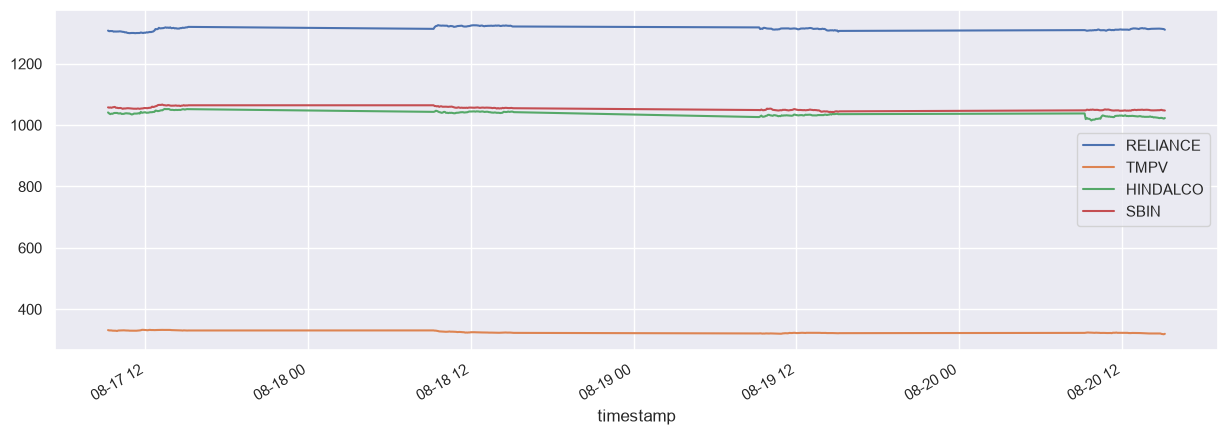

In [5]:
fig, ax = plt.subplots(figsize=(15, 5))
for ticker, df in data.items():
    df.reset_index().sort_values(by="timestamp").plot(x="timestamp", y="close", ax=ax, label=ticker)
plt.legend()
plt.show()

#### Candlestick chart (mplfinance)

findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight

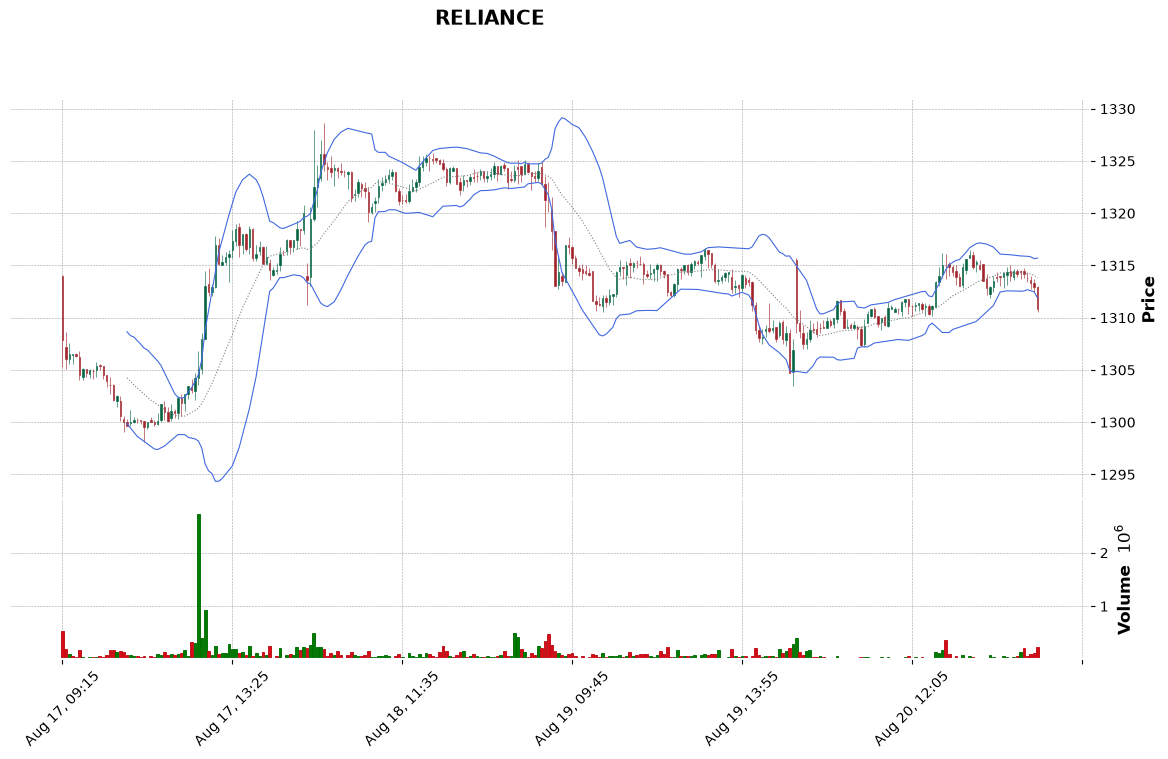

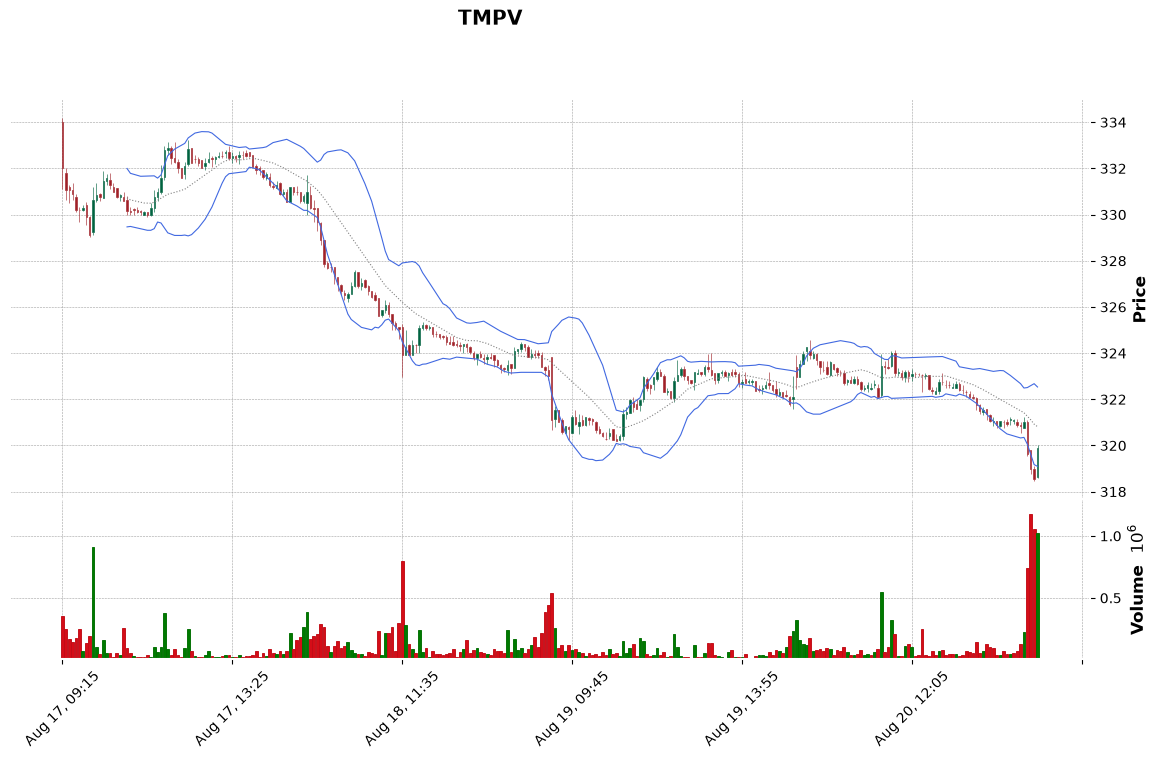

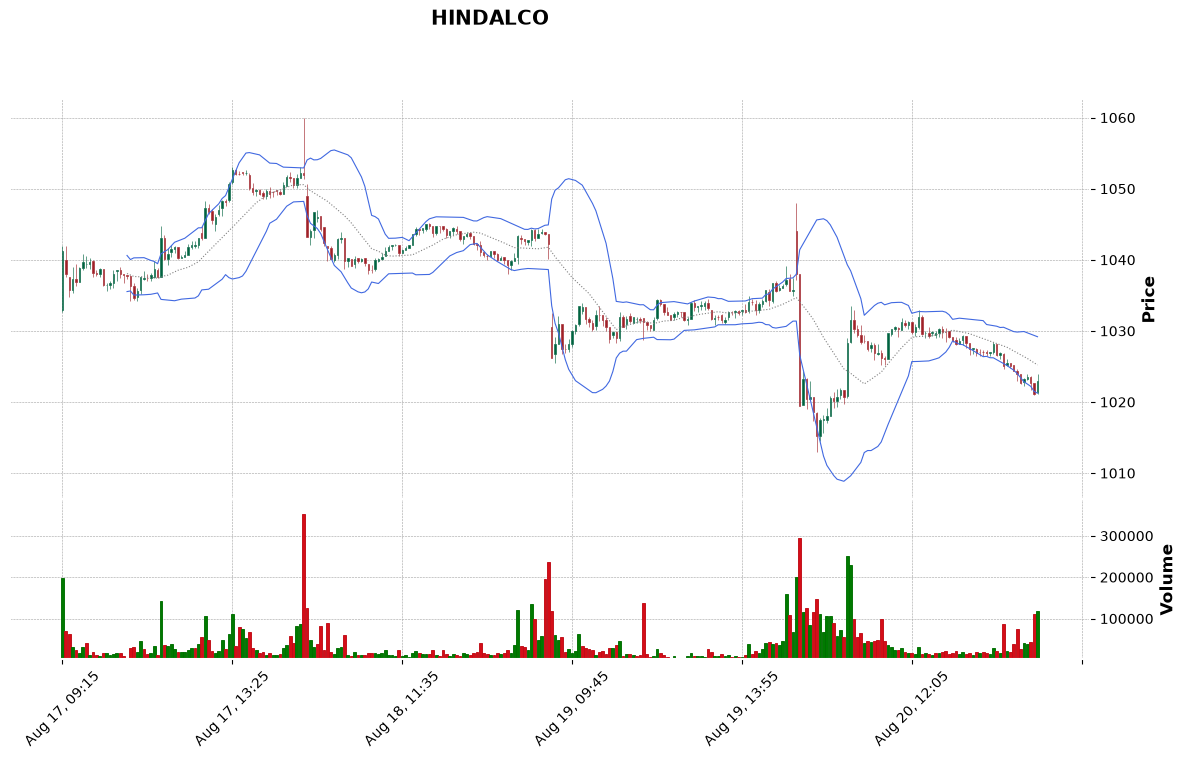

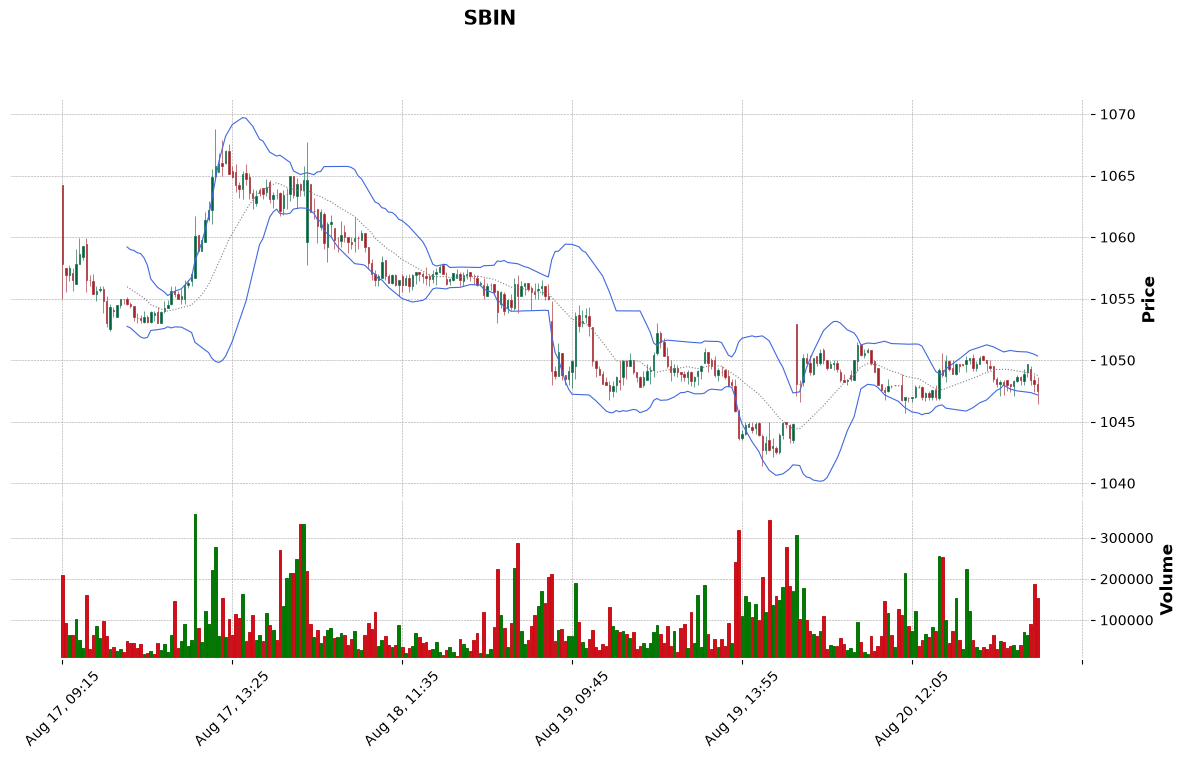

In [6]:
def make_candle_fig(df, title, figsize=(15, 8)):
    df_bb = df.copy()
    df_bb["bb_upper"], df_bb["bb_middle"], df_bb["bb_lower"] = talib.BBANDS(
        df_bb["close"].to_numpy(dtype=float),
        timeperiod=20,
        nbdevup=2.0,
        nbdevdn=2.0,
        matype=0,
    )
    addplots = [
        mpf.make_addplot(df_bb["bb_upper"], color="royalblue", width=0.8),
        mpf.make_addplot(df_bb["bb_middle"], color="gray", width=0.8, linestyle="dotted"),
        mpf.make_addplot(df_bb["bb_lower"], color="royalblue", width=0.8),
    ]
    fig, _ = mpf.plot(
        df_bb,
        type="candle",
        style="charles",
        addplot=addplots,
        volume=True,
        title=title,
        figsize=figsize,
        returnfig=True,
    )
    return fig

def plot_candles(df, title):
    fig = make_candle_fig(df, title)
    plt.show()
    plt.close(fig)

for ticker, df in data.items():
    plot_candles(df, ticker)

#### Order placemenet helper functions

In [7]:
def place_order(ticker, quantity, transaction_type):
    order_id = kite.place_order(
        variety=kite.VARIETY_REGULAR,
        exchange=kite.EXCHANGE_NSE,
        tradingsymbol=ticker.upper(),
        transaction_type=transaction_type,
        quantity=quantity,
        product=kite.PRODUCT_MIS,
        order_type=kite.ORDER_TYPE_MARKET,
        validity=kite.VALIDITY_DAY,
        market_protection=-1
    )

    return order_id


def place_buy_order(ticker, quantity):
    return place_order(
        ticker=ticker,
        quantity=quantity,
        transaction_type=kite.TRANSACTION_TYPE_BUY
    )


def square_off(ticker, quantity):
    return place_order(
        ticker=ticker,
        quantity=quantity,
        transaction_type=kite.TRANSACTION_TYPE_SELL
    )

#### Encoding the strategy (Long only)

    Step 1: Check if position already exists or not

In [8]:
def positions(ticker):
    daily_positions = kite.positions()["day"]
    if not daily_positions:
        return 0

    positions_df = pd.DataFrame(daily_positions)[["tradingsymbol", "instrument_token", "product", "quantity", "last_price"]]
    positions_df = positions_df[positions_df["tradingsymbol"] == ticker.upper()]

    if positions_df.empty:
        return 0

    return positions_df["quantity"].to_list()[0]

    Mark all entry conditions, exit conditions and middle bar conditions

### Per-ticker strategy logic (one instance runs per ticker)

In [9]:
import numpy as np
import pandas as pd


class LONGSTRATEGY:
    """Bollinger Band pyramiding, long only. One instance per ticker."""

    def __init__(self, ticker, quantity, max_entries=5, bb_period=20, bb_dev=2.0):
        self.ticker = ticker
        self.quantity = quantity          # qty per tranche
        self.max_entries = max_entries    # total tranches incl. initial entry
        self.bb_period = bb_period
        self.bb_dev = bb_dev

        self.enteries_taken = 0
        self.df = None
        self.log = []   # one row per closed bar, kept in memory while the bot runs

    # ---------- indicators ----------
    def add_bollinger_bands(self):
        df = self.df.copy()
        df["bb_upper"], df["bb_middle"], df["bb_lower"] = talib.BBANDS(
            df["close"].to_numpy(dtype=float),
            timeperiod=self.bb_period,
            nbdevup=self.bb_dev,
            nbdevdn=self.bb_dev,
            matype=0,
        )
        df.dropna(inplace=True)
        self.df = df
        return self

    # ---------- signals ----------
    def create_conditions(self):
        df = self.df.copy()

        df["entry_conditions"] = np.where(df["close"] <= df["bb_lower"], 1, 0)
        df["exit_conditions"] = np.where(df["close"] >= df["bb_upper"], -1, 0)

        df["positions"] = df["entry_conditions"] + df["exit_conditions"]
        df["positions"] = np.where(df["positions"] == 0, np.nan, df["positions"])
        df["positions"] = df["positions"].ffill()

        # armed once price reclaims the middle band; disarmed by any lower-band touch
        df["criteria_2"] = np.where(
            df["entry_conditions"] == 1, 0,
            np.where(df["close"] >= df["bb_middle"], 1, np.nan),
        )
        df["criteria_2"] = df["criteria_2"].ffill()

        prev_pos = df["positions"].shift(1)
        prev_armed = df["criteria_2"].shift(1)

        df["fresh_entry"] = np.where(
            (df["entry_conditions"] == 1) & (prev_pos != 1), 1, 0
        )
        df["add_position"] = np.where(
            (df["entry_conditions"] == 1) & (prev_pos == 1) & (prev_armed == 1), 1, 0
        )

        self.df = df
        return self

    # ---------- logging ----------
    def _log_bar(self, bar_time, status, action):
        self.log.append({
            "timestamp": bar_time,
            "ticker": self.ticker,
            "open": status["open"],
            "high": status["high"],
            "low": status["low"],
            "close": status["close"],
            "volume": status["volume"],
            "bb_upper": status["bb_upper"],
            "bb_middle": status["bb_middle"],
            "bb_lower": status["bb_lower"],
            "touched_lower": bool(status["close"] <= status["bb_lower"]),
            "touched_middle": bool(status["close"] >= status["bb_middle"]),
            "touched_upper": bool(status["close"] >= status["bb_upper"]),
            "fresh_entry": bool(status["fresh_entry"] == 1),
            "add_position": bool(status["add_position"] == 1),
            "exit_signal": bool(status["exit_conditions"] == -1),
            "action": action,
            "entries_taken": self.enteries_taken,
        })

    def to_dataframe(self):
        return pd.DataFrame(self.log)

    def save_log(self, path=None):
        """Dump the in-memory bar log to CSV. Meant to be called when the bot stops."""
        if not self.log:
            print(f"[{self.ticker}] no bars logged, nothing to save")
            return None

        path = path or f"{self.ticker}_bar_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
        self.to_dataframe().to_csv(path, index=False)
        print(f"[{self.ticker}] saved {len(self.log)} bars to {path}")
        return path

    # ---------- main loop ----------
    def on_event(self, df):
        self.df = df.copy()
        self.add_bollinger_bands()
        self.create_conditions()

        if len(self.df) < 2:
            print(f"[{self.ticker}] not enough bars")
            return self

        bar_time = self.df.index[-1]
        status = self.df.iloc[-1].to_dict()   # last CLOSED bar
        print(f"[{self.ticker}] bar close: {status['close']:.2f} "
              f"(lower {status['bb_lower']:.2f} | mid {status['bb_middle']:.2f} | upper {status['bb_upper']:.2f})")

        if status["close"] <= status["bb_lower"]:
            print(f"[{self.ticker}] touched LOWER band")
        if status["close"] >= status["bb_middle"]:
            print(f"[{self.ticker}] touched/above MIDDLE band")
        if status["close"] >= status["bb_upper"]:
            print(f"[{self.ticker}] touched UPPER band")

        active_positions = positions(self.ticker)
        action = "NONE"

        # resync if the position was closed outside this loop
        # (MIS auto square-off, manual exit, stop hit)
        if active_positions == 0 and self.enteries_taken > 0:
            print(f"[{self.ticker}] position closed externally, resetting counter")
            self.enteries_taken = 0

        if active_positions > 0:
            print(f"[{self.ticker}] position ONGOING: qty={active_positions}, "
                  f"entries_taken={self.enteries_taken}/{self.max_entries}, last_close={status['close']:.2f}")

            if status["exit_conditions"] == -1:
                print(f"[{self.ticker}] EXIT {active_positions}")
                square_off(self.ticker, active_positions)
                # TODO: confirm fill before resetting
                self.enteries_taken = 0
                action = "EXIT"

            elif (self.enteries_taken < self.max_entries
                  and status["add_position"] == 1):
                print(f"[{self.ticker}] ADD rung {self.enteries_taken + 1}")
                place_buy_order(self.ticker, self.quantity)
                # TODO: confirm fill before incrementing
                self.enteries_taken += 1
                action = "ADD"

        else:
            # Use the raw band touch, not the "fresh_entry" signal state, since
            # `positions` is computed over the full multi-day lookback and can
            # already be stuck at 1 from a touch before this bot session even
            # started (no upper-band close since). active_positions == 0 is
            # already the real guard against double-entering, so requiring
            # fresh_entry on top of it can permanently lock out a flat ticker.
            if status["entry_conditions"] == 1:
                print(f"[{self.ticker}] FRESH ENTRY")
                place_buy_order(self.ticker, self.quantity)
                # TODO: confirm fill before setting
                self.enteries_taken = 1
                action = "ENTRY"

        self._log_bar(bar_time, status, action)

        return self

### Creating bar events

#### Fetch historical bars

In [10]:
data = {
    ticker: fetch_historical_data(kite, instrument_token=token, interval=interval)
    for ticker, token in TICKERS.items()
}
for ticker, df in data.items():
    print(f"--- {ticker} ---")
    print(df.tail())

--- RELIANCE ---
                             open    high     low   close  volume
timestamp                                                        
2026-08-20 14:50:00+05:30  1314.5  1314.8  1313.8  1314.2  223746
2026-08-20 14:55:00+05:30  1313.8  1314.4  1313.4  1313.8   66829
2026-08-20 15:00:00+05:30  1313.6  1314.0  1312.7  1313.3   98598
2026-08-20 15:05:00+05:30  1313.3  1313.7  1312.5  1312.9  125986
2026-08-20 15:10:00+05:30  1312.9  1313.0  1310.5  1310.8  229256
--- TMPV ---
                             open    high     low   close   volume
timestamp                                                         
2026-08-20 14:50:00+05:30  320.75  321.25  320.75  321.00   226767
2026-08-20 14:55:00+05:30  321.00  321.10  319.55  319.65   738496
2026-08-20 15:00:00+05:30  319.80  319.80  318.75  319.00  1176448
2026-08-20 15:05:00+05:30  319.00  319.10  318.45  318.55  1057646
2026-08-20 15:10:00+05:30  318.65  320.00  318.60  319.90  1026434
--- HINDALCO ---
                      

#### Fetch websocket

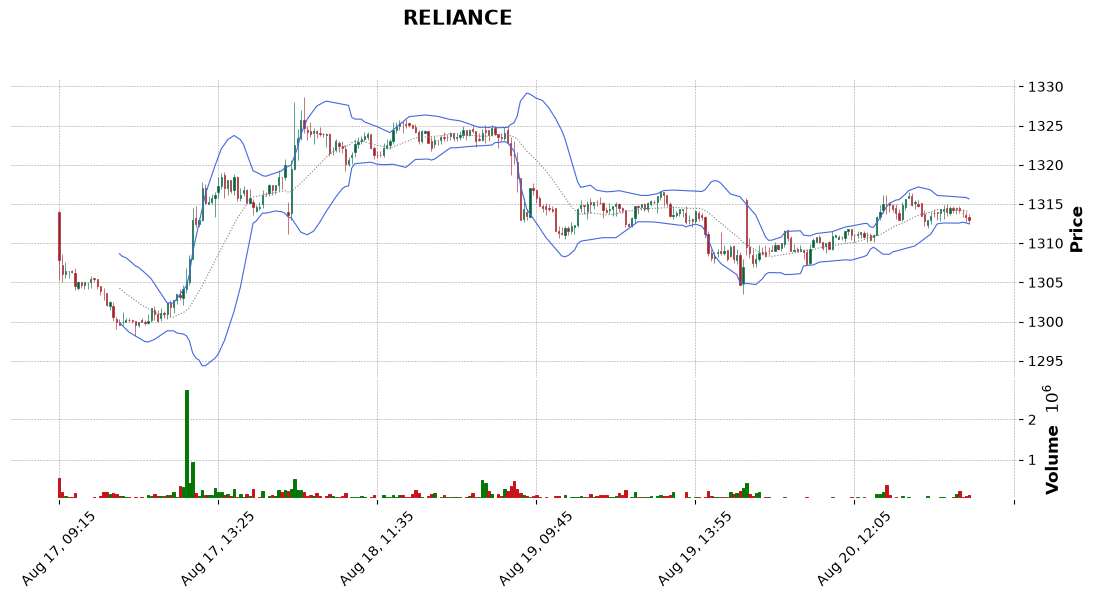

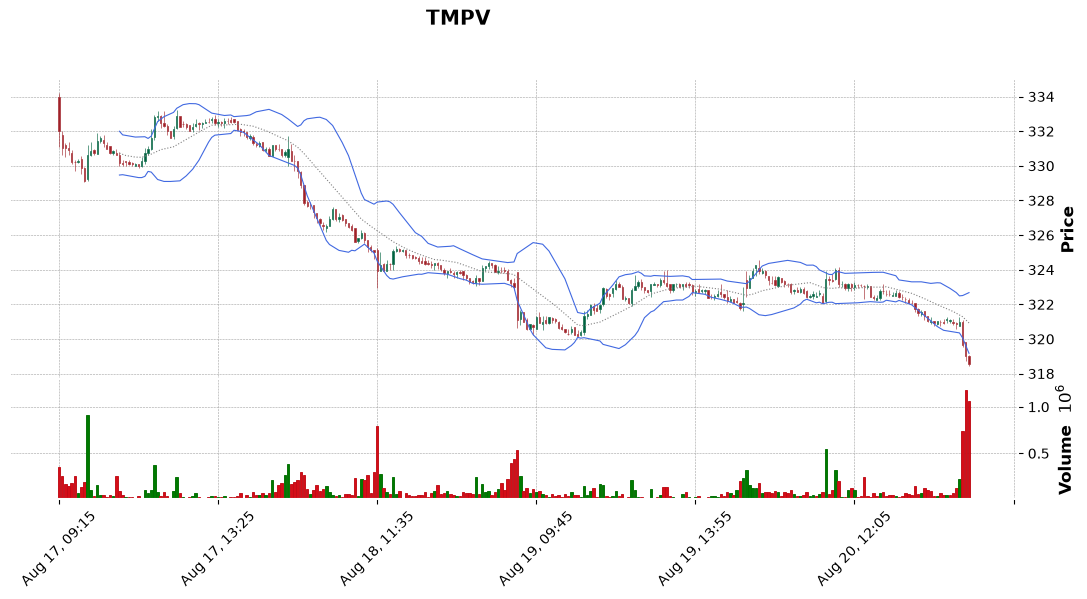

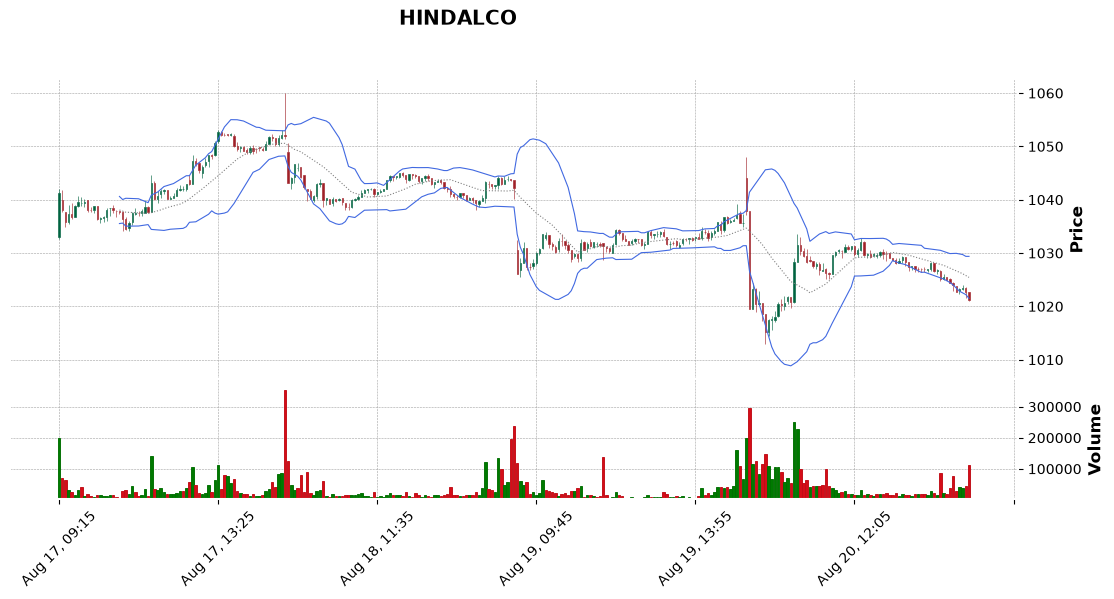

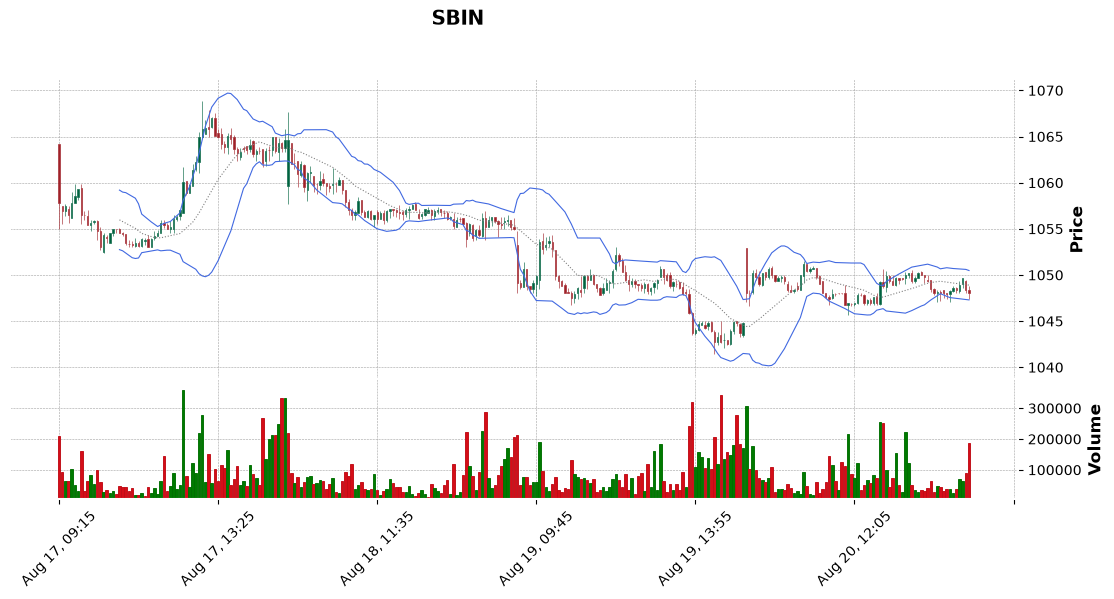

Bot Started
Bot Started
Bot Started
Bot Started


Connection error: 1006 - connection was closed uncleanly (peer dropped the TCP connection without previous WebSocket closing handshake)
Connection closed: 1006 - connection was closed uncleanly (peer dropped the TCP connection without previous WebSocket closing handshake)
Unhandled Error
Traceback (most recent call last):
  File "d:\execution_engine\venv\Lib\site-packages\twisted\python\log.py", line 97, in callWithLogger
    return callWithContext({"system": lp}, func, *args, **kw)
  File "d:\execution_engine\venv\Lib\site-packages\twisted\python\log.py", line 81, in callWithContext
    return context.call({ILogContext: newCtx}, func, *args, **kw)
  File "d:\execution_engine\venv\Lib\site-packages\twisted\python\context.py", line 116, in callWithContext
    return self.currentContext().callWithContext(ctx, func, *args, **kw)
  File "d:\execution_engine\venv\Lib\site-packages\twisted\python\context.py", line 81, in callWithContext
    return func(*args, **kw)
  File "d:\execution_engin

[RELIANCE] no bars logged, nothing to save
[TMPV] no bars logged, nothing to save
[HINDALCO] no bars logged, nothing to save
[SBIN] no bars logged, nothing to save


In [11]:
from BarAggregator import BarAggregator
from IPython.display import display, update_display

secret = get_zerodha_secret()
kws = KiteTicker(secret["api_key"], secret["access_token"])

instrument_tokens = list(TICKERS.values())
token_to_ticker = {token: ticker for ticker, token in TICKERS.items()}
chart_display_ids = {ticker: f"chart-{ticker}" for ticker in TICKERS}

ba = BarAggregator(instrument_tokens)
ba.prime(kite)

# one strategy instance per ticker, tracking its own entries/log independently
strategies = {
    token: LONGSTRATEGY(ticker, quantity=QUANTITY.get(ticker, 1))
    for ticker, token in TICKERS.items()
}

def show_chart(ticker, df):
    """First render for this ticker — creates its own persistent output slot."""
    fig = make_candle_fig(df, ticker, figsize=(14, 6))
    display(fig, display_id=chart_display_ids[ticker])
    plt.close(fig)

def update_chart(ticker, df):
    """Re-render in place, only touching this ticker's output slot."""
    fig = make_candle_fig(df, ticker, figsize=(14, 6))
    update_display(fig, display_id=chart_display_ids[ticker])
    plt.close(fig)

# seed one chart per ticker up front, stacked in the output; each updates
# independently below as its own bars close
for token in instrument_tokens:
    ticker = token_to_ticker[token]
    show_chart(ticker, ba.state[token]["historical_df"])

def on_ticks(ws, ticks):
    for tick in ticks:
        result = ba.create_bar(tick, kite)
        if result is not None:
            token, bar_df = result
            ticker = token_to_ticker[token]
            update_chart(ticker, bar_df)
            strategies[token].on_event(bar_df)

def on_connect(ws, response):
    ws.subscribe(instrument_tokens)

def on_close(ws, code, reason):
    ws.stop()

kws.on_ticks = on_ticks
kws.on_connect = on_connect
kws.on_close = on_close

# kws.connect() blocks until the ws is stopped (manual interrupt, ws.stop(), or a
# fatal error). Whenever that happens, treat it as "the bot stopped" and flush
# whatever bars are sitting in memory to CSV for every ticker.
try:
    kws.connect()
except KeyboardInterrupt:
    print("Bot stopped manually (KeyboardInterrupt)")
finally:
    for strategy in strategies.values():
        strategy.save_log()


#### Plot entries / adds / exits on the chart

In [ ]:
def plot_signals(strategy):
    """Candlestick + Bollinger bands with markers at logged ENTRY/ADD/EXIT bars.
    Uses strategy.df (last processed bars, already has bb_* columns) and
    strategy.log (event history) — call any time after the bot has run, even
    after it's stopped."""
    if strategy.df is None or not strategy.log:
        print(f"[{strategy.ticker}] nothing to plot yet")
        return

    df_bb = strategy.df
    log_df = strategy.to_dataframe().set_index("timestamp")

    def marker_series(action, price_col, offset):
        times = log_df.index[log_df["action"] == action].intersection(df_bb.index)
        s = pd.Series(np.nan, index=df_bb.index)
        s.loc[times] = df_bb.loc[times, price_col] * offset
        return s

    entry_markers = marker_series("ENTRY", "low", 0.995)
    add_markers = marker_series("ADD", "low", 0.99)
    exit_markers = marker_series("EXIT", "high", 1.005)

    addplots = [
        mpf.make_addplot(df_bb["bb_upper"], color="royalblue", width=0.8),
        mpf.make_addplot(df_bb["bb_middle"], color="gray", width=0.8, linestyle="dotted"),
        mpf.make_addplot(df_bb["bb_lower"], color="royalblue", width=0.8),
    ]
    if entry_markers.notna().any():
        addplots.append(mpf.make_addplot(entry_markers, type="scatter", markersize=120, marker="^", color="green"))
    if add_markers.notna().any():
        addplots.append(mpf.make_addplot(add_markers, type="scatter", markersize=80, marker="^", color="limegreen"))
    if exit_markers.notna().any():
        addplots.append(mpf.make_addplot(exit_markers, type="scatter", markersize=120, marker="v", color="red"))

    mpf.plot(
        df_bb,
        type="candle",
        style="charles",
        addplot=addplots,
        volume=True,
        title=f"{strategy.ticker} — entries (green ▲) / adds (lime ▲) / exits (red ▼)",
        figsize=(15, 8),
    )

for strategy in strategies.values():
    plot_signals(strategy)